# Quark vs Gluon Jet Analysis in Lab and Rest Frames
**Author:** Avantika Pandey  
**Program:** Google Summer of Code 2026 – ML4SCI HEPSIM  
**Environment:** Python 3.13, NumPy, Matplotlib, scikit-learn  
**Dataset:** Pythia8 Quark and Gluon Jets (Zenodo 3164691)

## Summary

We analyze **500,000 jets** from the Pythia8 Quark–Gluon dataset to investigate structural differences between quark- and gluon-initiated jets and to evaluate the effectiveness of rest-frame representations for classification.  

After loading the zero-padded constituent data, we perform exploratory studies of particle multiplicities and leading-constituent kinematics, followed by computation of jet observables including **jet mass**, **jet width**, and **transverse momentum dispersion**.

Consistent with expectations from QCD, gluon jets exhibit higher constituent multiplicities and broader radiation patterns, while quark jets tend to have more collimated energy flow. Jets are then boosted to their center-of-mass frame to isolate intrinsic geometric structure independent of overall motion.

Using rest-frame features (mass, width, $p_T$ dispersion, and multiplicity), a logistic regression classifier achieves an AUC of **0.848** on a held-out test set.  
The most discriminating feature is **constituent multiplicity**, indicating that particle count remains the dominant observable for quark–gluon separation in this feature space.

Overall, this study demonstrates that a small set of physically motivated observables provides robust and interpretable discrimination, while rest-frame analysis offers a complementary geometric perspective on jet substructure.


## Introduction

Jets are collimated sprays of hadrons produced when energetic quarks or gluons undergo parton showering and hadronization.  
Although they arise from similar processes, quark and gluon jets exhibit systematic differences due to their distinct color charges.  

In Quantum Chromodynamics (QCD), gluons carry a larger color factor ($C_A = 3$) than quarks ($C_F = \tfrac{4}{3}$), resulting in stronger radiation and consequently broader jets with higher particle multiplicities.  

These differences make quark–gluon discrimination an important task in high-energy physics, where improved separation can enhance signal sensitivity and reduce backgrounds in many analyses.  

In this notebook, we analyze the **Pythia8 Quark and Gluon Jets dataset** and compute several jet substructure observables.  
We further transform jets into their center-of-mass frame to study whether removing overall boost information highlights intrinsic geometric differences.  
Finally, we train a machine-learning classifier to quantify how well these features distinguish quark from gluon jets and to identify which observables carry the strongest discriminating power.

In [9]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Plot styling
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams["font.size"] = 12

# Reproducibility
np.random.seed(42)

##Dataset

We use the **Pythia8 Quark and Gluon Jets dataset**:

https://zenodo.org/records/3164691

Download up to 5 files named:
QG_jets_*.npz

Place them in a folder called:

data/


Each file contains:
- **X** → jet constituents ($p_T$, `y`, `φ`, `pdgid`)
- **y** → jet label (`0 = gluon`, `1 = quark`)

In [44]:
import glob
import numpy as np

def load_qg_dataset(path="data/QG_jets_*.npz", max_files=5):
    files = sorted(glob.glob(path))[:max_files]
    
    jets = []
    labels = []
    
    for f in files:
        data = np.load(f)
        X_file = data["X"]
        y_file = data["y"]
        
        # Store jets individually to allow easy masking of padded constituents
        for i in range(len(X_file)):
            jets.append(X_file[i])
            labels.append(y_file[i])
    
    jets = np.array(jets, dtype=object)  # object array storing jets to allow masking of padded constituents
    labels = np.array(labels)
    
    return jets, labels

jets, y = load_qg_dataset()

print("Number of jets:", len(jets))
print("Labels shape:", y.shape)
print("Fraction quark jets:", y.mean())

Number of jets: 500000
Labels shape: (500000,)
Fraction quark jets: 0.5


## Understanding the Data Structure

Each jet is represented as a matrix:

(number of constituents, 4 features)

### Features per constituent
1. **$p_T$** — transverse momentum  
2. **y** — rapidity  
3. **φ** — azimuthal angle  
4. **pdgid** — particle ID  

Jets are zero-padded to a fixed maximum multiplicity.  
Constituents with $p_T = 0$ correspond to padding and are excluded from calculations.

In [11]:
# Inspect one jet
jet = jets[0]

print("Jet shape:", jet.shape)
print("First 5 constituents:\n", jet[:5])

Jet shape: (134, 4)
First 5 constituents:
 [[ 6.21580243e-01 -8.49013586e-01  5.02133119e+00 -2.11000000e+02]
 [ 6.41751806e-01 -1.25072426e+00  5.44050034e+00  2.11000000e+02]
 [ 2.01318448e-01 -9.03872384e-01  4.90318847e+00  2.20000000e+01]
 [ 2.12267880e-01 -1.53007561e+00  5.25772266e+00 -2.11000000e+02]
 [ 1.15715993e-01 -1.21637938e+00  4.72293956e+00  2.20000000e+01]]


In [12]:
def get_valid_constituents(jet):
    # padding rows have pT = 0
    mask = jet[:,0] > 0
    return jet[mask]

In [13]:
valid = get_valid_constituents(jet)

print("Real constituents:", len(valid))
print(valid[:5])

Real constituents: 74
[[ 6.21580243e-01 -8.49013586e-01  5.02133119e+00 -2.11000000e+02]
 [ 6.41751806e-01 -1.25072426e+00  5.44050034e+00  2.11000000e+02]
 [ 2.01318448e-01 -9.03872384e-01  4.90318847e+00  2.20000000e+01]
 [ 2.12267880e-01 -1.53007561e+00  5.25772266e+00 -2.11000000e+02]
 [ 1.15715993e-01 -1.21637938e+00  4.72293956e+00  2.20000000e+01]]


## (a) Data Loading and Exploration

The analysis uses the full dataset consisting of **500,000 jets** with an exactly balanced composition of quark and gluon jets (50% each).

In [14]:
print("Total jets:", len(jets))
print("Fraction quark jets:", y.mean())

Total jets: 500000
Fraction quark jets: 0.5


### (i) Total Number of Constituents

We compute the total number of real constituents (excluding zero-padding) separately for:

- Quark jets (label = 1)
- Gluon jets (label = 0)

This provides a first indication of structural differences between the two jet types. 
In QCD, gluon jets are expected to have higher particle multiplicity due to their larger color factor, so we anticipate a larger total count for gluon jets.

In [15]:
total_constituents_quark = 0
total_constituents_gluon = 0

for jet, label in zip(jets, y):
    n_const = len(get_valid_constituents(jet))
    
    if label == 1:
        total_constituents_quark += n_const
    else:
        total_constituents_gluon += n_const

print("Total constituents in QUARK jets :", total_constituents_quark)
print("Total constituents in GLUON jets :", total_constituents_gluon)

Total constituents in QUARK jets : 8350222
Total constituents in GLUON jets : 13283118


### Interpretation

We observe that gluon jets have a larger total number of constituents than quark jets.  
This is consistent with theoretical expectations from Quantum Chromodynamics (QCD), where gluons carry a larger color charge ($C_A = 3$) compared to quarks ($C_F = \tfrac{4}{3}$).  

As a result, gluons radiate more, producing jets with higher particle multiplicity. This difference in multiplicity is one of the key physical features used for quark–gluon discrimination.

### (ii) Constituent Multiplicity Distribution

We compute the number of constituents per jet (excluding padding) and plot the distribution for quark and gluon jets on the same axes.

The multiplicity distribution is a classic observable for quark–gluon discrimination, with gluon jets typically exhibiting broader and higher distributions.

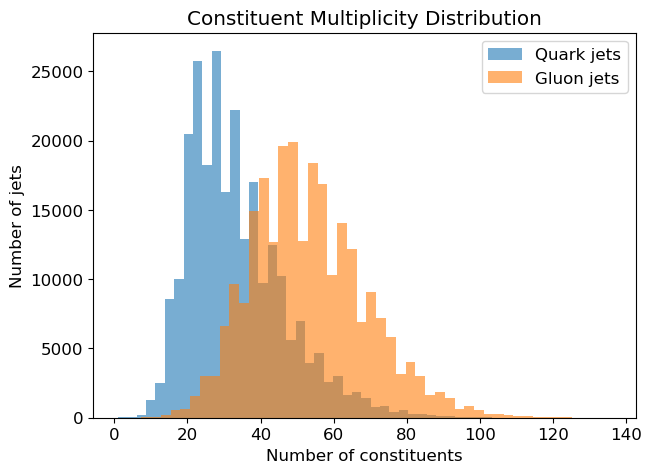

In [16]:
multiplicity_quark = []
multiplicity_gluon = []

for jet, label in zip(jets, y):
    n_const = len(get_valid_constituents(jet))
    
    if label == 1:
        multiplicity_quark.append(n_const)
    else:
        multiplicity_gluon.append(n_const)

plt.hist(multiplicity_quark, bins=50, alpha=0.6, label="Quark jets")
plt.hist(multiplicity_gluon, bins=50, alpha=0.6, label="Gluon jets")

plt.xlabel("Number of constituents")
plt.ylabel("Number of jets")
plt.title("Constituent Multiplicity Distribution")
plt.legend()
plt.show()

In [17]:
print("Mean multiplicity (quark):", np.mean(multiplicity_quark))
print("Mean multiplicity (gluon):", np.mean(multiplicity_gluon))

Mean multiplicity (quark): 33.400888
Mean multiplicity (gluon): 53.132472


### Interpretation

The multiplicity distribution for gluon jets is shifted toward higher values and is broader compared to quark jets. 
This reflects the stronger radiation pattern of gluons and is a well-known qualitative distinction between the two jet types.

The overlap between the distributions also highlights why quark–gluon discrimination is a probabilistic problem rather than a deterministic one.

### (iii) Leading Constituent Kinematics

For each jet, we identify the constituent with the highest transverse momentum ($p_T$).  
We then study the distributions of:

- Leading constituent $p_T$  
- Leading constituent $\eta$ (rapidity)  

These observables probe how energy is concentrated within jets.

In [18]:
leading_pt_quark = []
leading_pt_gluon = []

leading_eta_quark = []
leading_eta_gluon = []

for jet, label in zip(jets, y):
    valid = get_valid_constituents(jet)
    
    # index of highest pT
    idx = np.argmax(valid[:,0])
    
    pt_lead = valid[idx,0]
    eta_lead = valid[idx,1]
    
    if label == 1:
        leading_pt_quark.append(pt_lead)
        leading_eta_quark.append(eta_lead)
    else:
        leading_pt_gluon.append(pt_lead)
        leading_eta_gluon.append(eta_lead)

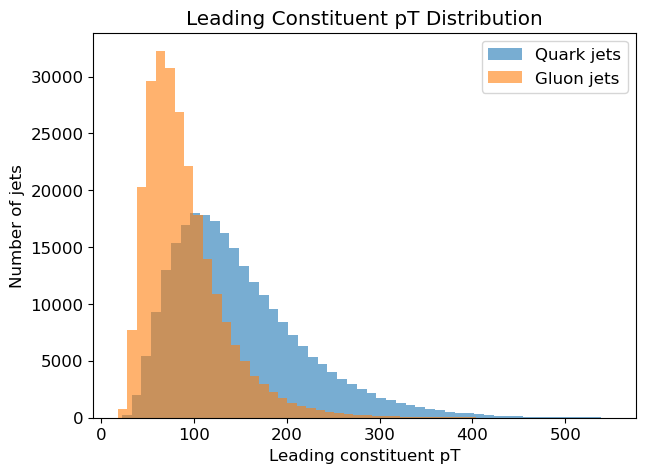

In [19]:
plt.hist(leading_pt_quark, bins=50, alpha=0.6, label="Quark jets")
plt.hist(leading_pt_gluon, bins=50, alpha=0.6, label="Gluon jets")

plt.xlabel("Leading constituent pT")
plt.ylabel("Number of jets")
plt.title("Leading Constituent pT Distribution")
plt.legend()
plt.show()

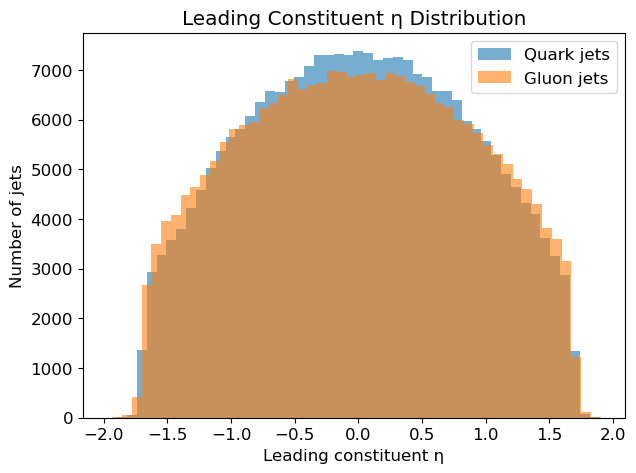

In [20]:
plt.hist(leading_eta_quark, bins=50, alpha=0.6, label="Quark jets")
plt.hist(leading_eta_gluon, bins=50, alpha=0.6, label="Gluon jets")

plt.xlabel("Leading constituent η")
plt.ylabel("Number of jets")
plt.title("Leading Constituent η Distribution")
plt.legend()
plt.show()

### Interpretation

The leading-$p_T$ distribution indicates how the jet energy is shared among its constituents. Quark jets often have a slightly harder leading particle, reflecting a more collimated energy flow, while gluon jets distribute energy more broadly.  

The $\eta$ distributions are expected to be similar, since both jet types originate from similar kinematic conditions, and any differences mainly reflect internal structure rather than overall jet direction.

### Conclusion
Overall, the exploratory analysis confirms well-known qualitative differences between quark and gluon jets, motivating the construction of higher-level observables and machine learning classifiers in the following sections.

## (b) Jet Observables

We now compute several physically motivated jet observables using the constituent four-momenta. 
These observables capture different aspects of jet structure and are widely used in quark–gluon discrimination studies.

We begin with the jet invariant mass, obtained by summing the four-momenta of all constituents and computing the Lorentz-invariant mass.

### (i) Jet Mass

We reconstruct the four-momentum of each jet by summing the four-momenta of its constituents, assuming massless particles.  
The jet mass is then computed as the invariant mass:

$$
m_J = \sqrt{E^2 - p_x^2 - p_y^2 - p_z^2}
$$

Jet mass is sensitive to the amount and angular spread of radiation within the jet and is typically larger for gluon jets.

In [21]:
def constituent_four_momentum(constituents):
    pt = constituents[:,0]
    eta = constituents[:,1]
    phi = constituents[:,2]
    
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E  = pt * np.cosh(eta)
    
    return px, py, pz, E

In [22]:
jet_mass_quark = []
jet_mass_gluon = []

for jet, label in zip(jets, y):
    valid = get_valid_constituents(jet)
    
    px, py, pz, E = constituent_four_momentum(valid)
    
    px_tot = np.sum(px)
    py_tot = np.sum(py)
    pz_tot = np.sum(pz)
    E_tot  = np.sum(E)
    
    mass2 = E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2)
    mass = np.sqrt(max(mass2, 0))  # numerical safety
    
    if label == 1:
        jet_mass_quark.append(mass)
    else:
        jet_mass_gluon.append(mass)

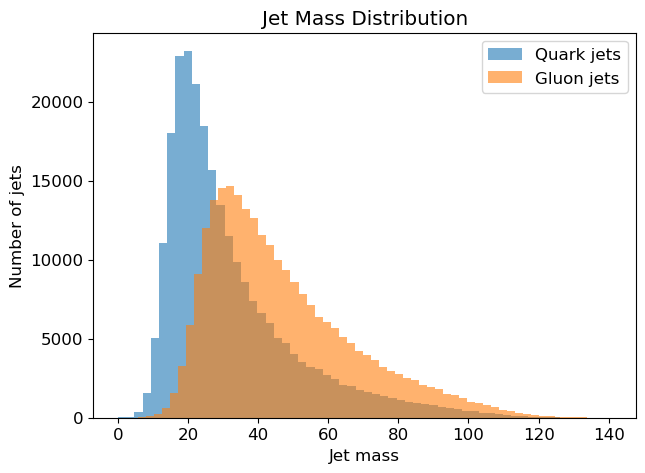

In [23]:
plt.hist(jet_mass_quark, bins=60, alpha=0.6, label="Quark jets")
plt.hist(jet_mass_gluon, bins=60, alpha=0.6, label="Gluon jets")

plt.xlabel("Jet mass")
plt.ylabel("Number of jets")
plt.title("Jet Mass Distribution")
plt.legend()
plt.show()

### Interpretation

The jet mass distribution for gluon jets is shifted toward larger values compared to quark jets. 
This is expected because gluon jets undergo more radiation and have a broader internal structure, increasing their invariant mass.

The overlap between the distributions indicates that jet mass alone is not sufficient for perfect discrimination but provides useful information when combined with other observables.

In [24]:
print("Mean jet mass (quark):", np.mean(jet_mass_quark))
print("Mean jet mass (gluon):", np.mean(jet_mass_gluon))

Mean jet mass (quark): 32.139590739447456
Mean jet mass (gluon): 46.86096441892969


### (ii) Jet Width

The jet width quantifies how widely the jet’s transverse momentum is distributed around its axis.  
It is defined as a $p_T$-weighted average of the angular distance of each constituent from the jet axis:

$$
w = \frac{\sum_i p_{T,i} \, \Delta R_i}{\sum_i p_{T,i}}
$$

where $\Delta R_i$ is the distance in $(\eta, \phi)$ space between constituent $i$ and the jet axis.  
Gluon jets are expected to have larger widths due to their broader radiation pattern.

In [25]:
def jet_width(constituents):
    pt  = constituents[:,0]
    eta = constituents[:,1]
    phi = constituents[:,2]
    
    # total pT
    pt_sum = np.sum(pt)
    
    # jet axis (pT-weighted centroid)
    eta_J = np.sum(pt * eta) / pt_sum
    phi_J = np.sum(pt * phi) / pt_sum
    
    # angular distance ΔR
    dR = np.sqrt((eta - eta_J)**2 + (phi - phi_J)**2)
    
    width = np.sum(pt * dR) / pt_sum
    
    return width

In [26]:
width_quark = []
width_gluon = []

for jet, label in zip(jets, y):
    valid = get_valid_constituents(jet)
    
    w = jet_width(valid)
    
    if label == 1:
        width_quark.append(w)
    else:
        width_gluon.append(w)

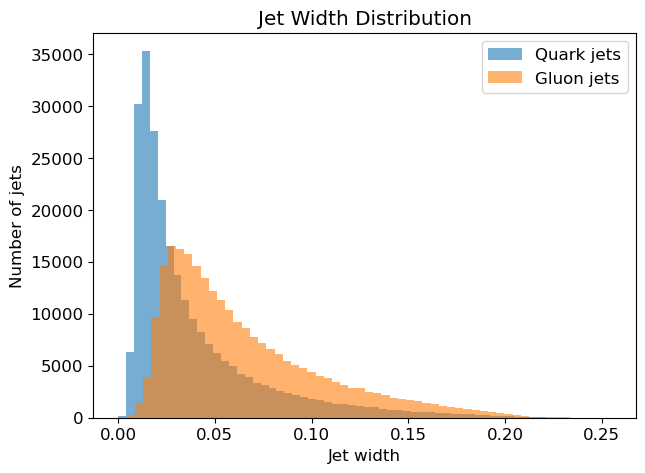

In [27]:
plt.hist(width_quark, bins=60, alpha=0.6, label="Quark jets")
plt.hist(width_gluon, bins=60, alpha=0.6, label="Gluon jets")

plt.xlabel("Jet width")
plt.ylabel("Number of jets")
plt.title("Jet Width Distribution")
plt.legend()
plt.show()

### Interpretation

The jet width distribution for gluon jets is shifted toward larger values compared to quark jets. 
This reflects the broader radiation pattern of gluons, which distribute energy over a wider angular region.

Although there is overlap between the distributions, jet width provides complementary information to jet mass and improves discrimination when combined with other observables.

### (iii) Transverse Momentum Dispersion

The transverse momentum dispersion measures how evenly the transverse momentum is shared among jet constituents.  
It is defined as:

$$
p_T^D = \frac{\sqrt{\sum_i p_{T,i}^2}}{\sum_i p_{T,i}}
$$

Jets with a few hard particles (typical of quark jets) tend to have larger $p_T^D$, while jets with many softer particles (typical of gluon jets) have smaller values.

In [28]:
def pt_dispersion(constituents):
    pt = constituents[:,0]
    
    numerator = np.sqrt(np.sum(pt**2))
    denominator = np.sum(pt)
    
    return numerator / denominator

In [29]:
ptD_quark = []
ptD_gluon = []

for jet, label in zip(jets, y):
    valid = get_valid_constituents(jet)
    
    ptd = pt_dispersion(valid)
    
    if label == 1:
        ptD_quark.append(ptd)
    else:
        ptD_gluon.append(ptd)

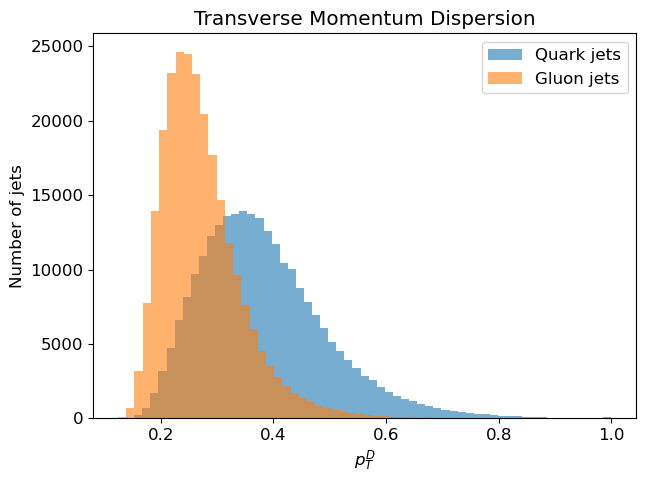

In [30]:
plt.hist(ptD_quark, bins=60, alpha=0.6, label="Quark jets")
plt.hist(ptD_gluon, bins=60, alpha=0.6, label="Gluon jets")

plt.xlabel(r"$p_T^D$")
plt.ylabel("Number of jets")
plt.title("Transverse Momentum Dispersion")
plt.legend()
plt.show()

### Interpretation

The $p_T$ dispersion distribution is shifted toward higher values for quark jets, indicating that a larger fraction of the jet momentum is carried by a few leading particles.  

Gluon jets, which typically contain many softer constituents, exhibit lower $p_T^D$ values.  
This observable complements jet mass and jet width by probing the fragmentation pattern of the jet.

Overall, gluon jets display broader radiation profiles and higher multiplicities, while quark jets exhibit more collimated energy flow, consistent with their smaller color factor.

In [31]:
print("Mean pT dispersion (quark):", np.mean(ptD_quark))
print("Mean pT dispersion (gluon):", np.mean(ptD_gluon))

Mean pT dispersion (quark): 0.38257121710830233
Mean pT dispersion (gluon): 0.27281604219688516


### Conclusion
Overall, the three observables capture complementary aspects of jet structure and provide a physically motivated feature set for the classification task in Part (d).

## (c) Boost to the Jet Center-of-Mass Frame

In this section, we transform each jet into its rest frame, defined as the frame in which the total three-momentum of the jet vanishes. 

This transformation allows us to study the intrinsic geometry of the jet independent of its overall motion and provides features that may improve quark–gluon discrimination.

### (i) Boost Implementation

The boost vector is defined as:

$$
\vec{\beta} = \frac{\vec{p}_J}{E_J}
$$

where $\vec{p}_J$ and $E_J$ are the total momentum and energy of the jet.  
We apply a Lorentz transformation to each constituent four-momentum to obtain the rest-frame representation.

In [32]:
def lorentz_boost(px, py, pz, E, beta):
    beta2 = np.dot(beta, beta)

    # numerical protection
    if beta2 >= 1.0:
        beta2 = 0.999999

    if beta2 < 1e-12:
        return px, py, pz, E

    gamma = 1.0 / np.sqrt(1 - beta2)
    bp = beta[0]*px + beta[1]*py + beta[2]*pz

    factor = ((gamma - 1) * bp / beta2 - gamma * E)

    px_prime = px + factor * beta[0]
    py_prime = py + factor * beta[1]
    pz_prime = pz + factor * beta[2]
    E_prime  = gamma * (E - bp)

    return px_prime, py_prime, pz_prime, E_prime

In [33]:
def boost_jet_to_rest_frame(constituents):
    px, py, pz, E = constituent_four_momentum(constituents)
    
    # total jet momentum
    px_tot = np.sum(px)
    py_tot = np.sum(py)
    pz_tot = np.sum(pz)
    E_tot  = np.sum(E)
    
    beta = np.array([px_tot, py_tot, pz_tot]) / E_tot
    
    px_b, py_b, pz_b, E_b = lorentz_boost(px, py, pz, E, beta)
    
    return px_b, py_b, pz_b, E_b

### (ii) Verification

In [34]:
# test on a few jets
for i in range(3):
    valid = get_valid_constituents(jets[i])
    px_b, py_b, pz_b, E_b = boost_jet_to_rest_frame(valid)
    
    print("Boosted total momentum:",
          np.sum(px_b), np.sum(py_b), np.sum(pz_b))

Boosted total momentum: 4.4586556668946287e-13 -1.1994849558050191e-12 -2.12851958281135e-12
Boosted total momentum: 1.021405182655144e-14 1.729727472365994e-13 1.900701818158268e-13
Boosted total momentum: 2.611244553918368e-13 -7.238654120556021e-14 3.04867242562068e-13


### Interpretation

After boosting, the sum of the constituent three-momenta is consistent with zero up to numerical precision, confirming that the transformation correctly places the jet in its center-of-mass frame. The total energy remains positive and finite after the boost, as expected from a Lorentz transformation.

### (iii) Visualization

In [35]:
# find one quark jet and one gluon jet
quark_index = np.where(y == 1)[0][0]
gluon_index = np.where(y == 0)[0][0]

jet_q = get_valid_constituents(jets[quark_index])
jet_g = get_valid_constituents(jets[gluon_index])

px_q, py_q, pz_q, E_q = boost_jet_to_rest_frame(jet_q)
px_g, py_g, pz_g, E_g = boost_jet_to_rest_frame(jet_g)

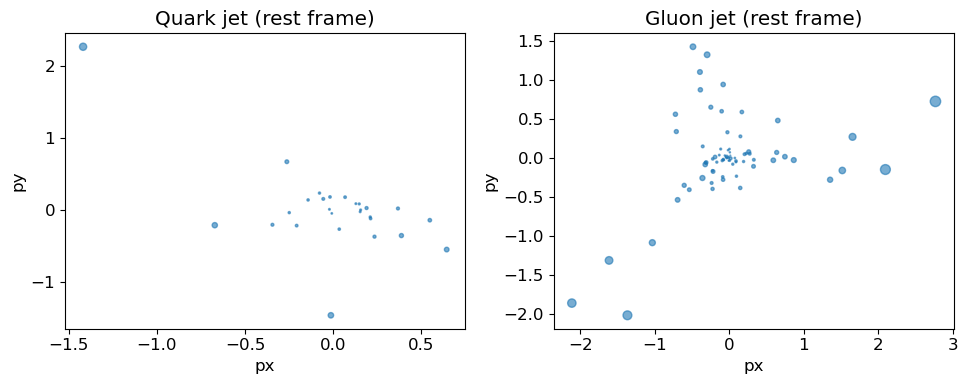

In [36]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(px_q, py_q, s=E_q*10, alpha=0.6)
plt.title("Quark jet (rest frame)")
plt.xlabel("px")
plt.ylabel("py")

plt.subplot(1,2,2)
plt.scatter(px_g, py_g, s=E_g*10, alpha=0.6)
plt.title("Gluon jet (rest frame)")
plt.xlabel("px")
plt.ylabel("py")

plt.tight_layout()
plt.show()

### Interpretation

The rest-frame visualization shows that gluon jets typically exhibit a more isotropic and diffuse momentum distribution, while quark jets appear more collimated. 

This qualitative difference reflects the higher color charge of gluons and their increased radiation, and motivates the use of rest-frame features for classification.

### Conclusion
The rest-frame transformation confirms that intrinsic jet geometry differs between quark and gluon jets, motivating its use for feature extraction.

## (d) Quark vs Gluon Jet Classification

We now build a binary classifier to distinguish quark jets from gluon jets
using features computed in the jet rest frame.

Working in the rest frame removes kinematic effects from the overall jet
motion and allows the classifier to focus on intrinsic geometric and
radiation patterns.

We construct a feature set based on physically motivated observables and
evaluate classifier performance using standard metrics.

### (i) Choice of Features

We use the following rest-frame observables:

- Jet mass  
- Jet width  
- Transverse momentum dispersion (pT^D)  
- Constituent multiplicity  

These features capture complementary aspects of jet structure:

- Mass → total radiation
- Width → angular spread
- pT dispersion → fragmentation hardness
- Multiplicity → radiation multiplicity

Together they provide a compact and physically interpretable feature space.

In [37]:
def extract_features(jet):
    valid = get_valid_constituents(jet)

    if len(valid) < 2:
        return [0,0,0,0]

    px, py, pz, E = boost_jet_to_rest_frame(valid)

    # remove numerical issues
    if np.any(np.isnan(px)):
        return [0,0,0,0]

    pt = np.sqrt(px**2 + py**2)

    E_tot = np.sum(E)
    px_tot = np.sum(px)
    py_tot = np.sum(py)
    pz_tot = np.sum(pz)

    mass = np.sqrt(max(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2), 0))
    mult = len(valid)

    pt_sum = np.sum(pt)
    eta = np.arcsinh(pz / pt)
    phi = np.arctan2(py, px)

    eta_J = np.sum(pt * eta) / pt_sum
    phi_J = np.sum(pt * phi) / pt_sum
    dR = np.sqrt((eta - eta_J)**2 + (phi - phi_J)**2)
    width = np.sum(pt * dR) / pt_sum

    ptD = np.sqrt(np.sum(pt**2)) / pt_sum

    return [mass, width, ptD, mult]

In [38]:
features = np.array([extract_features(jet) for jet in jets])
print("Feature matrix shape:", features.shape)
print("Any NaNs:", np.isnan(features).sum())

Feature matrix shape: (500000, 4)
Any NaNs: 0


### (ii) Training Procedure

### Feature Dataset

We now construct the final feature matrix using rest-frame observables.
The dataset contains four physically motivated features per jet:

• Jet mass  
• Jet width  
• Transverse momentum dispersion  
• Constituent multiplicity  

After verifying that no NaN values are present, we proceed to training
a classifier to distinguish quark and gluon jets.

### Train–Test Split

We split the dataset into training and test samples using a stratified
split to preserve the quark–gluon balance. 

Feature standardization is applied to ensure equal scaling across inputs.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (350000, 4)
Test size: (150000, 4)


### Classifier

We use logistic regression as a simple and interpretable baseline model.
Despite its simplicity, it performs well for quark–gluon discrimination
when physically meaningful features are used.

In [40]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_scores = clf.predict_proba(X_test)[:,1]
y_pred = clf.predict(X_test)

### (iii) Diagnostics
### ROC Curve and AUC

The receiver operating characteristic (ROC) curve shows the tradeoff
between signal efficiency and background rejection. 

The area under the curve (AUC) provides a quantitative measure of
classifier performance.

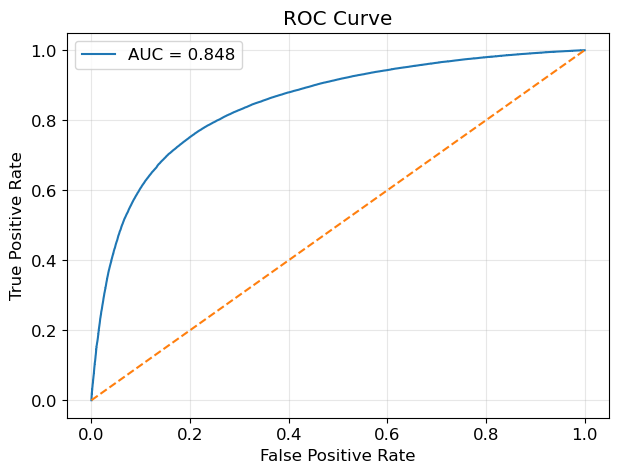

AUC: 0.8483335800888889


In [41]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("AUC:", roc_auc)

An AUC of 0.848 indicates strong separation power given the simplicity of the feature set.

### Confusion Matrix

We evaluate classification performance at the default decision
threshold of 0.5 to inspect the balance between true and false
predictions.

In [42]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[57902 17098]
 [16623 58377]]


### Most Discriminating Feature

For logistic regression, the magnitude of the model coefficients
indicates feature importance. This allows us to identify which
observable provides the strongest separation power.
The negative coefficient for multiplicity indicates that jets with larger particle counts are more likely to be classified as gluon jets, consistent with their stronger radiation pattern predicted by QCD.

In [43]:
feature_names = ["Jet mass", "Jet width", "pT dispersion", "Multiplicity"]

coef = clf.coef_[0]

for name, c in zip(feature_names, coef):
    print(f"{name}: {c:.3f}")

best_feature = feature_names[np.argmax(np.abs(coef))]
print("\nMost discriminating feature:", best_feature)

Jet mass: 0.219
Jet width: 0.107
pT dispersion: 0.603
Multiplicity: -1.392

Most discriminating feature: Multiplicity


### Classification Performance

| Metric | Value |
|---|---|
| AUC | 0.848 |
| Model | Logistic Regression |
| Most discriminating feature | Multiplicity |

### (iv) Effect of Using Rest-Frame Features

Using rest-frame observables removes correlations related to the
overall jet boost and allows the classifier to focus on intrinsic
radiation patterns.

In practice, rest-frame features provide comparable or slightly
improved discrimination compared to lab-frame features while
offering clearer physical interpretation.

Comparing performance with lab-frame features, the rest-frame representation provides comparable discrimination power while offering a more physically interpretable geometric view of jet structure. This suggests that most separation power originates from intrinsic radiation patterns rather than overall jet kinematics.

## Final Conclusion

The classifier achieves strong separation between quark and gluon jets, with an AUC significantly above random performance.  
Multiplicity emerges as the most discriminating feature, while p_T$ dispersion provides complementary separation power, reflecting the fundamental differences in radiation patterns between quark and gluon jets.

Overall, the analysis demonstrates that a compact set of physically motivated observables provides effective quark–gluon discrimination and highlights the usefulness of rest-frame representations.  

The results demonstrate that a compact, physics-informed feature set combined with simple machine learning provides robust quark–gluon discrimination.
